
# TwinCar - CompCars EfficientNet-B0 make + model + year classifier

This is a self-contained CompCars-only experiment for a fine-grained label:

`make + model + year`, for example `Audi A5 2013`.

This notebook is intentionally kept **separate from the Stanford Cars experiments**.
It is useful as an optional CompCars benchmark because year-level labels are harder
and more sparse than make/model-only labels.

In [2]:
import os
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

TARGET              = "make_model_year"
IMG_SIZE            = 224
BATCH_SIZE          = 64          
EPOCHS              = 10         
LR                  = 3e-4
WEIGHT_DECAY        = 1e-4
PATIENCE            = 3           
LR_PATIENCE         = 2
LABEL_SMOOTHING     = 0.1
DROPOUT             = 0.3
USE_PRETRAINED      = True        

VIEWPOINTS          = None        
USE_BBOX_CROP       = True        
BBOX_MARGIN         = 0.08

MIN_IMAGES_PER_CLASS = 15
MAX_IMAGES_PER_CLASS = None       

TEST_FRAC = 0.15
VAL_FRAC  = 0.15

OUTPUT_DIR = Path("/kaggle/working/compcars_efficientnet_b0_mmy_fixed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_WORKERS = 2 if device.type == "cuda" else 0
PIN_MEMORY = device.type == "cuda"

print("Device:", device)
print("NUM_WORKERS:", NUM_WORKERS)
print("Output dir:", OUTPUT_DIR)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Training will be very slow. Enable GPU before training.")


Device: cuda
NUM_WORKERS: 2
Output dir: /kaggle/working/compcars_efficientnet_b0_mmy_fixed
GPU: Tesla T4


## 1. Locate the CompCars dataset

Found by locating `misc/make_model_name.mat`, so it works whether the dataset mounts
at `/kaggle/input/compcars` or the nested `.../datasets/renancostaalencar/compcars`.

In [3]:

def find_compcars_root(search_root="/kaggle/input"):
    """Find CompCars root on Kaggle without printing or walking every image path."""
    search_root = Path(search_root)

    likely_paths = [
        search_root / "compcars" / "misc" / "make_model_name.mat",
        search_root / "datasets" / "renancostaalencar" / "compcars" / "misc" / "make_model_name.mat",
    ]

    for mat_path in likely_paths:
        if mat_path.exists():
            return mat_path.parent.parent, mat_path

    candidates = list(search_root.glob("**/misc/make_model_name.mat"))
    if not candidates:
        raise FileNotFoundError(
            "make_model_name.mat not found under /kaggle/input. "
            "Attach the CompCars dataset using Add Input."
        )

    mat_path = sorted(candidates, key=lambda p: len(p.parts))[0]
    return mat_path.parent.parent, mat_path


def resolve_dir(root, name):
    """Find a required CompCars directory, usually image/ or label/."""
    root = Path(root)
    direct = root / name
    if direct.exists():
        return direct

    matches = [p for p in root.glob(f"**/{name}") if p.is_dir()]
    if matches:
        return sorted(matches, key=lambda p: len(p.parts))[0]

    raise FileNotFoundError(f"No '{name}' directory found under {root}")


COMPCARS_ROOT, MAT_PATH = find_compcars_root()
IMAGE_ROOT = resolve_dir(COMPCARS_ROOT, "image")
LABEL_ROOT = resolve_dir(COMPCARS_ROOT, "label")

print("CompCars root:", COMPCARS_ROOT)
print("MAT path     :", MAT_PATH)
print("Image root   :", IMAGE_ROOT)
print("Label root   :", LABEL_ROOT)

assert MAT_PATH.exists()
assert IMAGE_ROOT.exists()
assert LABEL_ROOT.exists()


CompCars root: /kaggle/input/datasets/renancostaalencar/compcars
MAT path     : /kaggle/input/datasets/renancostaalencar/compcars/misc/make_model_name.mat
Image root   : /kaggle/input/datasets/renancostaalencar/compcars/image
Label root   : /kaggle/input/datasets/renancostaalencar/compcars/label


## 2. Make / model name tables and the Stanford-make restriction

We load both `make_names` and `model_names` from the `.mat` file. Make names come from
the verified CompCars->Stanford mapping (Stanford spelling); model names come from the
CompCars model table. The leaf label is `"<make> <model> <year>"`.

In [4]:

mat = scipy.io.loadmat(str(MAT_PATH))
make_names_tbl = mat["make_names"].ravel()
model_names_tbl = mat["model_names"].ravel()


def mat_cell_to_str(x):
    """Convert nested MATLAB cell/string objects into a clean Python string."""
    while isinstance(x, np.ndarray):
        if x.size == 0:
            return ""
        if x.dtype.kind in ("U", "S"):
            return "".join(x.ravel().astype(str)).strip()
        x = x.flat[0]
    return str(x).strip()


def raw_make_name_for(make_id):
    try:
        return mat_cell_to_str(make_names_tbl[int(make_id) - 1])
    except Exception:
        return f"make{make_id}"


def model_name_for(model_id):
    try:
        return mat_cell_to_str(model_names_tbl[int(model_id) - 1])
    except Exception:
        return f"model{model_id}"

matched_make_ids = {
    6: "Fisker", 7: "GMC", 11: "Jeep", 15: "MINI", 21: "Scion",
    22: "Tesla", 26: "smart", 28: "Mitsubishi", 30: "Spyker",
    39: "Toyota", 42: "Isuzu", 48: "Porsche", 50: "Chrysler",
    51: "Lamborghini", 53: "Cadillac", 57: "Rolls-Royce", 73: "Volkswagen",
    77: "Mercedes-Benz", 78: "Audi", 83: "Bentley", 85: "Bugatti",
    92: "Jaguar", 97: "Nissan", 100: "Honda", 101: "Lincoln",
    111: "Volvo", 112: "Ferrari", 118: "Hyundai", 122: "Ford",
    131: "Infiniti", 134: "FIAT", 139: "Acura", 142: "Land Rover",
    143: "McLaren", 144: "Maybach", 145: "Dodge", 149: "Suzuki",
    154: "Aston Martin", 162: "Mazda",
    81: "BMW",      # CompCars typo: BWM
    54: "Buick",    # CompCars typo: Buck
}


def clean_model_name(make_id, clean_make, raw_model):
    """Remove duplicated make prefixes and known CompCars typos from model names.

    Examples:
    Audi Audi A5 -> Audi A5
    Acura Acura ILX -> Acura ILX
    BMW BWM 3 Series -> BMW 3 Series
    Mercedes-Benz Benz B Class -> Mercedes-Benz B Class
    """
    model = str(raw_model).strip()
    raw_make = raw_make_name_for(make_id).strip()

    prefixes_to_remove = [
        clean_make,
        raw_make,
        raw_make.replace("-", " "),
        "BWM", "BMW",
        "Benz", "Mercedes-Benz", "Mercedes Benz",
        "Buck", "Buick",
        "LAND-ROVER", "Land Rover", "Land-Rover",
        "Lamorghini", "Lamborghini",
    ]

    changed = True
    while changed:
        changed = False
        for prefix in prefixes_to_remove:
            prefix = str(prefix).strip()
            if not prefix:
                continue
            pattern = r"^" + re.escape(prefix) + r"\s+"
            new_model = re.sub(pattern, "", model, flags=re.IGNORECASE).strip()
            if new_model != model:
                model = new_model
                changed = True

    model = re.sub(r"\s+", " ", model).strip()
    return model if model else str(raw_model).strip()


print("Matched makes:", len(matched_make_ids))
print("Make spot check:", {mid: raw_make_name_for(mid) for mid in [54, 77, 78, 81, 139]})
print("Model spot check:", {mid: model_name_for(mid) for mid in [1, 100, 500]})


Matched makes: 41
Make spot check: {54: 'Buck', 77: 'Benz', 78: 'Audi', 81: 'BWM', 139: 'Acura'}
Model spot check: {1: 'Audi A3 hatchback', 100: 'BWM 6 Series', 500: 'Bora'}



## 3. Build the filtered image index

Each leaf folder `image/<make_id>/<model_id>/<year>/` becomes one fine-grained class.
This fixed version cleans repeated make prefixes in model names and preloads
viewpoint/bounding-box metadata once during indexing.


In [5]:

def parse_label_file(path):
    """Return (viewpoint, bbox) from a CompCars label file.

    bbox is returned as (x1, y1, x2, y2), or None if missing.
    """
    viewpoint, bbox = None, None
    try:
        with open(path) as f:
            lines = [ln.strip() for ln in f if ln.strip()]
    except OSError:
        return None, None

    for ln in lines:
        toks = ln.replace(",", " ").split()
        ints = []
        ok = True
        for t in toks:
            try:
                ints.append(int(float(t)))
            except ValueError:
                ok = False
                break
        if not ok:
            continue

        if viewpoint is None and len(ints) == 1:
            viewpoint = ints[0]
        elif bbox is None and len(ints) == 4:
            bbox = tuple(ints)

    return viewpoint, bbox


def build_index():
    need_view = VIEWPOINTS is not None
    rows = []

    for make_id, make_name in matched_make_ids.items():
        make_img_dir = IMAGE_ROOT / str(make_id)
        if not make_img_dir.exists():
            continue

        for model_dir in make_img_dir.iterdir():
            if not model_dir.is_dir():
                continue

            try:
                model_id = int(model_dir.name)
            except ValueError:
                continue

            raw_model_name = model_name_for(model_id)
            model_name = clean_model_name(make_id, make_name, raw_model_name)
            make_model = f"{make_name} {model_name}".strip()

            for year_dir in model_dir.iterdir():
                if not year_dir.is_dir():
                    continue

                year_raw = year_dir.name
                year_label = "unknown" if year_raw in ("0", "unknown", "") else year_raw
                class_key = f"{make_id}_{model_id}_{year_raw}"
                class_name = f"{make_model} {year_label}".strip()

                for img_path in year_dir.glob("*.jpg"):
                    label_path = (
                        LABEL_ROOT / str(make_id) / model_dir.name /
                        year_raw / (img_path.stem + ".txt")
                    )

                    viewpoint, bbox = parse_label_file(label_path)
                    if need_view and viewpoint not in VIEWPOINTS:
                        continue

                    if bbox is None:
                        bbox_x1 = bbox_y1 = bbox_x2 = bbox_y2 = np.nan
                    else:
                        bbox_x1, bbox_y1, bbox_x2, bbox_y2 = bbox

                    rows.append({
                        "image_path": str(img_path),
                        "label_path": str(label_path),
                        "make_id": make_id,
                        "model_id": model_id,
                        "raw_model": raw_model_name,
                        "make": make_name,
                        "model": model_name,
                        "make_model": make_model,
                        "year": year_label,
                        "year_raw": year_raw,
                        "viewpoint": viewpoint,
                        "bbox_x1": bbox_x1,
                        "bbox_y1": bbox_y1,
                        "bbox_x2": bbox_x2,
                        "bbox_y2": bbox_y2,
                        "class_key": class_key,
                        "class_name": class_name,
                    })

    return pd.DataFrame(rows)


t0 = time.time()
index_df = build_index()
print(f"Indexed {len(index_df):,} images in {time.time() - t0:.0f}s")
print("Raw classes (make+model+year):", index_df["class_key"].nunique())
print("Distinct makes:", index_df["make"].nunique())
print("Distinct make+model:", index_df["make_model"].nunique())

# Safety check: model should no longer start with the make name.
dup_prefix = index_df.apply(
    lambda r: str(r["model"]).lower().startswith(str(r["make"]).lower() + " "),
    axis=1,
).sum()
print("Rows where cleaned model still starts with make:", int(dup_prefix))

index_df.head()


Indexed 69,099 images in 601s
Raw classes (make+model+year): 2241
Distinct makes: 41
Distinct make+model: 796
Rows where cleaned model still starts with make: 0


,image_path,label_path,make_id,model_id,raw_model,make,model,make_model,year,year_raw,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,class_key,class_name
0,/kaggle/input/datasets/renancostaalencar/compc...,/kaggle/input/datasets/renancostaalencar/compc...,6,1774,Surf,Fisker,Surf,Fisker Surf,2011,2011,4,145,126,674,421,6_1774_2011,Fisker Surf 2011
1,/kaggle/input/datasets/renancostaalencar/compc...,/kaggle/input/datasets/renancostaalencar/compc...,6,1774,Surf,Fisker,Surf,Fisker Surf,2011,2011,3,5,228,789,456,6_1774_2011,Fisker Surf 2011
2,/kaggle/input/datasets/renancostaalencar/compc...,/kaggle/input/datasets/renancostaalencar/compc...,6,1774,Surf,Fisker,Surf,Fisker Surf,2011,2011,3,32,298,868,583,6_1774_2011,Fisker Surf 2011
3,/kaggle/input/datasets/renancostaalencar/compc...,/kaggle/input/datasets/renancostaalencar/compc...,6,1774,Surf,Fisker,Surf,Fisker Surf,2011,2011,5,49,251,750,489,6_1774_2011,Fisker Surf 2011
4,/kaggle/input/datasets/renancostaalencar/compc...,/kaggle/input/datasets/renancostaalencar/compc...,6,1774,Surf,Fisker,Surf,Fisker Surf,2011,2011,4,28,154,772,491,6_1774_2011,Fisker Surf 2011


In [6]:
counts = index_df["class_key"].value_counts()

if MIN_IMAGES_PER_CLASS is not None and MIN_IMAGES_PER_CLASS > 1:
    keep = counts[counts >= MIN_IMAGES_PER_CLASS].index
    dropped_classes = int((counts < MIN_IMAGES_PER_CLASS).sum())
    dropped_imgs = int(counts[counts < MIN_IMAGES_PER_CLASS].sum())
    index_df = index_df[index_df["class_key"].isin(keep)].reset_index(drop=True)
    print(f"Dropped {dropped_classes} classes (<{MIN_IMAGES_PER_CLASS} images, {dropped_imgs} images).")
else:
    print("No minimum image filter applied.")

if MAX_IMAGES_PER_CLASS is not None:
    index_df = (
        index_df
        .groupby("class_key", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), MAX_IMAGES_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )
    print(f"Applied MAX_IMAGES_PER_CLASS = {MAX_IMAGES_PER_CLASS}")

final_counts = index_df["class_key"].value_counts()

class_keys = sorted(index_df["class_key"].unique())
key_to_idx = {k: i for i, k in enumerate(class_keys)}
index_df["label"] = index_df["class_key"].map(key_to_idx)
NUM_CLASSES = len(class_keys)

meta = (
    index_df
    .drop_duplicates("class_key")
    .set_index("class_key")[["class_name", "make", "model", "make_model", "year", "make_id", "model_id", "year_raw"]]
)
idx_to_meta = {key_to_idx[k]: meta.loc[k].to_dict() for k in class_keys}
class_names = [idx_to_meta[i]["class_name"] for i in range(NUM_CLASSES)]

print(f"Final: {NUM_CLASSES} make+model+year classes, {len(index_df):,} images")
print("Images/class — min:", int(final_counts.min()),
      "median:", int(final_counts.median()),
      "max:", int(final_counts.max()))

index_df.to_csv(OUTPUT_DIR / "compcars_mmy_index_filtered.csv", index=False)
print("Saved:", OUTPUT_DIR / "compcars_mmy_index_filtered.csv")


Dropped 604 classes (<15 images, 4883 images).
Final: 1637 make+model+year classes, 64,216 images
Images/class — min: 15 median: 30 max: 167
Saved: /kaggle/working/compcars_efficientnet_b0_mmy_fixed/compcars_mmy_index_filtered.csv


## 4. Train / val / test split (stratified by fine-grained class)

We build our own reproducible 70/15/15 split (`seed=42`); the `MIN_IMAGES_PER_CLASS`
filter guarantees every class can appear in all three splits.

In [7]:

train_val_df, test_df = train_test_split(
    index_df,
    test_size=TEST_FRAC,
    stratify=index_df["label"],
    random_state=SEED,
)

val_rel = VAL_FRAC / (1.0 - TEST_FRAC)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_rel,
    stratify=train_val_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("Classes in train:", train_df["label"].nunique(), "/", NUM_CLASSES)
print("Classes in val  :", val_df["label"].nunique(), "/", NUM_CLASSES)
print("Classes in test :", test_df["label"].nunique(), "/", NUM_CLASSES)

assert train_df["label"].nunique() == NUM_CLASSES
assert val_df["label"].nunique() == NUM_CLASSES
assert test_df["label"].nunique() == NUM_CLASSES

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)
print("Saved split CSV files to:", OUTPUT_DIR)


Train 44,950 | Val 9,633 | Test 9,633
Classes in train: 1637 / 1637
Classes in val  : 1637 / 1637
Classes in test : 1637 / 1637
Saved split CSV files to: /kaggle/working/compcars_efficientnet_b0_mmy_fixed



## 5. Dataset, augmentation & dataloaders

Augmentation mirrors the Stanford baseline and adds a light perspective transform for
oblique drone/robot-style images. Bounding boxes were already parsed during indexing,
so the dataset uses the stored bbox columns instead of reopening label `.txt` files
inside every epoch.


In [8]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class CompCarsDataset(Dataset):
    def __init__(self, df, transform, use_bbox_crop=USE_BBOX_CROP, margin=BBOX_MARGIN):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.use_bbox_crop = use_bbox_crop
        self.margin = margin

    def __len__(self):
        return len(self.df)

    def _crop(self, img, row):
        if not self.use_bbox_crop:
            return img

        bbox_values = [row.get("bbox_x1"), row.get("bbox_y1"), row.get("bbox_x2"), row.get("bbox_y2")]
        if any(pd.isna(v) for v in bbox_values):
            return img

        x1, y1, x2, y2 = [int(v) for v in bbox_values]
        if x2 <= x1 or y2 <= y1:
            return img

        w, h = img.size
        mw, mh = (x2 - x1) * self.margin, (y2 - y1) * self.margin
        x1 = max(0, int(x1 - mw))
        y1 = max(0, int(y1 - mh))
        x2 = min(w, int(x2 + mw))
        y2 = min(h, int(y2 + mh))

        if x2 <= x1 or y2 <= y1:
            return img

        return img.crop((x1, y1, x2, y2))

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row["image_path"]).convert("RGB")
            img = self._crop(img, row)
        except (OSError, ValueError):
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (128, 128, 128))

        return self.transform(img), int(row["label"])


train_dataset = CompCarsDataset(train_df, train_transforms)
val_dataset = CompCarsDataset(val_df, val_test_transforms)
test_dataset = CompCarsDataset(test_df, val_test_transforms)

train_counts = Counter(train_df["label"].tolist())
class_weight = {c: 1.0 / n for c, n in train_counts.items()}
sample_weights = [class_weight[l] for l in train_df["label"].tolist()]
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

with open(OUTPUT_DIR / "class_label_map.json", "w") as f:
    json.dump({str(i): idx_to_meta[i] for i in range(NUM_CLASSES)}, f, indent=2)

print("Batches -> train", len(train_loader), "val", len(val_loader), "test", len(test_loader))
print("Saved:", OUTPUT_DIR / "class_label_map.json")


Batches -> train 703 val 151 test 151
Saved: /kaggle/working/compcars_efficientnet_b0_mmy_fixed/class_label_map.json


## 6. Model: EfficientNet-B0 (fine-grained head)

In [9]:

def build_model(num_classes, dropout=DROPOUT, pretrained=USE_PRETRAINED):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    try:
        model = models.efficientnet_b0(weights=weights)
        if pretrained:
            print("Loaded ImageNet-pretrained EfficientNet-B0.")
    except Exception as e:
        print("WARNING: pretrained download failed. Using random initialization.")
        print("Original error:", repr(e))
        model = models.efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model


model = build_model(NUM_CLASSES).to(device)
print("Trainable params:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Classes:", NUM_CLASSES)

train_config = {
    "experiment": "compcars_efficientnet_b0_make_model_year_fixed",
    "model": "efficientnet_b0",
    "target": TARGET,
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "lr_patience": LR_PATIENCE,
    "label_smoothing": LABEL_SMOOTHING,
    "dropout": DROPOUT,
    "viewpoints": sorted(VIEWPOINTS) if VIEWPOINTS else "all",
    "use_bbox_crop": USE_BBOX_CROP,
    "bbox_margin": BBOX_MARGIN,
    "min_images_per_class": MIN_IMAGES_PER_CLASS,
    "max_images_per_class": MAX_IMAGES_PER_CLASS,
    "seed": SEED,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "n_train": len(train_df),
    "n_val": len(val_df),
    "n_test": len(test_df),
    "device": str(device),
    "num_workers": NUM_WORKERS,
}

with open(OUTPUT_DIR / "train_config.json", "w") as f:
    json.dump(train_config, f, indent=2)

print("Saved train_config.json")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


Loaded ImageNet-pretrained EfficientNet-B0.
Trainable params: 6,104,545
Classes: 1637
Saved train_config.json


## 7. Loss / optimizer / scheduler

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
print("Ready.")

Ready.


## 8. Training loop (early stopping; best checkpoint by val loss)

In [11]:

def run_epoch(model, loader, train=False):
    model.train() if train else model.eval()
    total_loss = 0.0
    correct1 = 0
    correct5 = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct1 += (logits.argmax(1) == labels).sum().item()

        k = min(5, logits.size(1))
        _, top5 = logits.topk(k, dim=1)
        correct5 += (top5 == labels.unsqueeze(1)).any(1).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct1 / n, correct5 / n


history = {
    "train_loss": [],
    "val_loss": [],
    "train_top1": [],
    "train_top5": [],
    "val_top1": [],
    "val_top5": [],
    "lr": [],
}

best_val_loss = float("inf")
best_path = OUTPUT_DIR / "best_model.pt"
wait = 0

print("=" * 70)
print("TRAINING EfficientNet-B0 — CompCars make+model+year")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_top1, tr_top5 = run_epoch(model, train_loader, train=True)
    va_loss, va_top1, va_top5 = run_epoch(model, val_loader, train=False)
    scheduler.step(va_loss)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(float(tr_loss))
    history["val_loss"].append(float(va_loss))
    history["train_top1"].append(float(tr_top1))
    history["train_top5"].append(float(tr_top5))
    history["val_top1"].append(float(va_top1))
    history["val_top5"].append(float(va_top5))
    history["lr"].append(float(lr_now))

    with open(OUTPUT_DIR / "training_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss {tr_loss:.4f} | val_loss {va_loss:.4f} | "
        f"train_top1 {tr_top1:.3f} | val_top1 {va_top1:.3f} | "
        f"val_top5 {va_top5:.3f} | lr {lr_now:.2e} | "
        f"{time.time() - t0:.0f}s"
    )

    if va_loss < best_val_loss - 1e-4:
        best_val_loss = va_loss
        wait = 0
        torch.save(model.state_dict(), best_path)
        print(f"  -> improved to {best_val_loss:.4f}; saved best_model.pt")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

best_idx = int(np.argmin(history["val_loss"]))
print(
    f"\nBest epoch {best_idx + 1} | "
    f"val_loss {history['val_loss'][best_idx]:.4f} | "
    f"val_top1 {history['val_top1'][best_idx]:.3f} | "
    f"val_top5 {history['val_top5'][best_idx]:.3f}"
)


TRAINING EfficientNet-B0 — CompCars make+model+year
Epoch 01/10 | train_loss 5.8733 | val_loss 4.6829 | train_top1 0.151 | val_top1 0.240 | val_top5 0.450 | lr 3.00e-04 | 651s
  -> improved to 4.6829; saved best_model.pt
Epoch 02/10 | train_loss 3.0646 | val_loss 3.3841 | train_top1 0.580 | val_top1 0.482 | val_top5 0.723 | lr 3.00e-04 | 433s
  -> improved to 3.3841; saved best_model.pt
Epoch 03/10 | train_loss 2.1877 | val_loss 2.9245 | train_top1 0.783 | val_top1 0.584 | val_top5 0.805 | lr 3.00e-04 | 412s
  -> improved to 2.9245; saved best_model.pt
Epoch 04/10 | train_loss 1.8564 | val_loss 2.6369 | train_top1 0.866 | val_top1 0.643 | val_top5 0.853 | lr 3.00e-04 | 406s
  -> improved to 2.6369; saved best_model.pt
Epoch 05/10 | train_loss 1.6906 | val_loss 2.5482 | train_top1 0.908 | val_top1 0.666 | val_top5 0.865 | lr 3.00e-04 | 411s
  -> improved to 2.5482; saved best_model.pt
Epoch 06/10 | train_loss 1.5864 | val_loss 2.4262 | train_top1 0.934 | val_top1 0.699 | val_top5 0.878 

## 9. Training curves

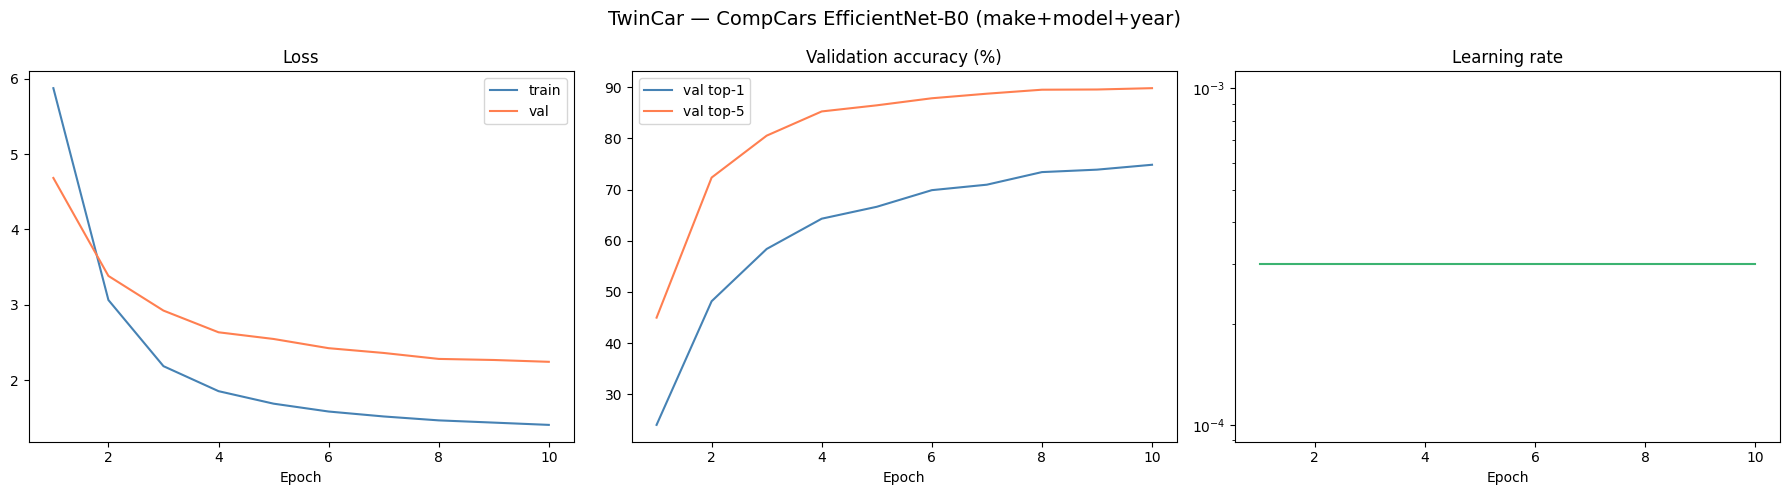

In [12]:
ep = list(range(1, len(history["train_loss"]) + 1))
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(ep, history["train_loss"], label="train", color="steelblue")
ax[0].plot(ep, history["val_loss"], label="val", color="coral")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(ep, [v*100 for v in history["val_top1"]], label="val top-1", color="steelblue")
ax[1].plot(ep, [v*100 for v in history["val_top5"]], label="val top-5", color="coral")
ax[1].set_title("Validation accuracy (%)"); ax[1].set_xlabel("Epoch"); ax[1].legend()
ax[2].plot(ep, history["lr"], color="mediumseagreen")
ax[2].set_title("Learning rate"); ax[2].set_xlabel("Epoch"); ax[2].set_yscale("log")
plt.suptitle("TwinCar — CompCars EfficientNet-B0 (make+model+year)", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

## 10. Evaluation on the held-out test set

Same metric family as the Stanford eval notebooks. From the predicted fine-grained
class we also derive **make**, **make+model** and **year** accuracy.

In [13]:

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()


def evaluate(model, loader, top_k=5):
    y_true, y_pred, y_conf, in_topk = [], [], [], []
    total_loss = 0.0
    n = 0
    crit = nn.CrossEntropyLoss()

    with torch.inference_mode():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(imgs)
                loss = crit(logits, labels)

            probs = torch.softmax(logits.float(), dim=1)
            conf, preds = probs.max(1)

            k = min(top_k, probs.size(1))
            _, topk = probs.topk(k, dim=1)
            hit = (topk == labels.unsqueeze(1)).any(1)

            total_loss += loss.item() * labels.size(0)
            n += labels.size(0)
            y_true += labels.cpu().tolist()
            y_pred += preds.cpu().tolist()
            y_conf += conf.cpu().tolist()
            in_topk += hit.cpu().tolist()

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_conf),
        np.array(in_topk),
        total_loss / n,
    )


t0 = time.time()
y_true, y_pred, y_conf, in_topk, test_loss = evaluate(model, test_loader, top_k=5)
print(f"Evaluated {len(y_true):,} images in {time.time() - t0:.0f}s | test loss {test_loss:.4f}")


def meta_field(idx_array, field):
    return np.array([idx_to_meta[int(i)][field] for i in idx_array])


pred_df = pd.DataFrame({
    "image_path": test_df["image_path"].values,
    "true_class": meta_field(y_true, "class_name"),
    "pred_class": meta_field(y_pred, "class_name"),
    "true_make": meta_field(y_true, "make"),
    "pred_make": meta_field(y_pred, "make"),
    "true_make_model": meta_field(y_true, "make_model"),
    "pred_make_model": meta_field(y_pred, "make_model"),
    "true_year": meta_field(y_true, "year"),
    "pred_year": meta_field(y_pred, "year"),
    "confidence": y_conf,
    "correct_exact": y_true == y_pred,
    "true_in_top5": in_topk,
})

pred_df["correct_make"] = pred_df["true_make"] == pred_df["pred_make"]
pred_df["correct_make_model"] = pred_df["true_make_model"] == pred_df["pred_make_model"]
pred_df["correct_year"] = pred_df["true_year"] == pred_df["pred_year"]

pred_df.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
print("Saved predictions.csv")
pred_df.head()


Evaluated 9,633 images in 95s | test loss 1.3100
Saved predictions.csv


,image_path,true_class,pred_class,true_make,pred_make,true_make_model,pred_make_model,true_year,pred_year,confidence,correct_exact,true_in_top5,correct_make,correct_make_model,correct_year
0,/kaggle/input/datasets/renancostaalencar/compc...,Mitsubishi GR-HEV 2013,Mitsubishi GR-HEV 2013,Mitsubishi,Mitsubishi,Mitsubishi GR-HEV,Mitsubishi GR-HEV,2013,2013,0.826905,True,True,True,True,True
1,/kaggle/input/datasets/renancostaalencar/compc...,MINI COUNTRYMAN 2012,MINI COUNTRYMAN 2012,MINI,MINI,MINI COUNTRYMAN,MINI COUNTRYMAN,2012,2012,0.273665,True,True,True,True,True
2,/kaggle/input/datasets/renancostaalencar/compc...,BMW 2 Series Active Tourer 2014,BMW 2 Series Active Tourer 2014,BMW,BMW,BMW 2 Series Active Tourer,BMW 2 Series Active Tourer,2014,2014,0.942256,True,True,True,True,True
3,/kaggle/input/datasets/renancostaalencar/compc...,Mercedes-Benz AMG GT 2015,Aston Martin Vanquish 2015,Mercedes-Benz,Aston Martin,Mercedes-Benz AMG GT,Aston Martin Vanquish,2015,2015,0.371773,False,True,False,False,True
4,/kaggle/input/datasets/renancostaalencar/compc...,Mercedes-Benz GLA Class 2015,Mercedes-Benz GLA Class 2015,Mercedes-Benz,Mercedes-Benz,Mercedes-Benz GLA Class,Mercedes-Benz GLA Class,2015,2015,0.519544,True,True,True,True,True


In [14]:

def m(fn, avg):
    return float(fn(y_true, y_pred, average=avg, zero_division=0))


year_rows = pred_df[pred_df["true_year"] != "unknown"]
correct_rows = pred_df[pred_df["correct_exact"]]
wrong_rows = pred_df[~pred_df["correct_exact"]]

metrics = {
    "experiment": "compcars_efficientnet_b0_make_model_year_fixed",
    "num_test_images": int(len(y_true)),
    "num_classes": NUM_CLASSES,
    "test_loss": float(test_loss),
    "exact_top1_accuracy": float(accuracy_score(y_true, y_pred)),
    "exact_top5_accuracy": float(in_topk.mean()),
    "exact_balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    "precision_macro": m(precision_score, "macro"),
    "recall_macro": m(recall_score, "macro"),
    "f1_macro": m(f1_score, "macro"),
    "precision_weighted": m(precision_score, "weighted"),
    "recall_weighted": m(recall_score, "weighted"),
    "f1_weighted": m(f1_score, "weighted"),
    "make_accuracy": float(pred_df["correct_make"].mean()),
    "make_model_accuracy": float(pred_df["correct_make_model"].mean()),
    "year_accuracy_when_known": float(year_rows["correct_year"].mean()) if len(year_rows) else float("nan"),
    "mean_confidence_correct": float(correct_rows["confidence"].mean()) if len(correct_rows) else float("nan"),
    "mean_confidence_wrong": float(wrong_rows["confidence"].mean()) if len(wrong_rows) else float("nan"),
    "model_file_size_mb": float(best_path.stat().st_size / 1e6),
}

with open(OUTPUT_DIR / "metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame([metrics]).to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)

print(f"Exact top-1 (make+model+year): {metrics['exact_top1_accuracy']*100:.2f}%")
print(f"Exact top-5                  : {metrics['exact_top5_accuracy']*100:.2f}%")
print(f"Make accuracy                : {metrics['make_accuracy']*100:.2f}%")
print(f"Make+model accuracy          : {metrics['make_model_accuracy']*100:.2f}%")
print(f"Year accuracy (when known)   : {metrics['year_accuracy_when_known']*100:.2f}%")
print(f"Weighted F1                  : {metrics['f1_weighted']:.4f}")
print(f"Balanced accuracy            : {metrics['exact_balanced_accuracy']*100:.2f}%")

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

per_class = (
    pd.DataFrame(report)
    .transpose()
    .loc[class_names, ["precision", "recall", "f1-score", "support"]]
)
per_class.to_csv(OUTPUT_DIR / "per_class_report.csv")

seen = per_class[per_class["support"] > 0].sort_values("f1-score")
print("\nWeakest 10 classes by F1:")
print(seen.head(10).round(3))
print("\nStrongest 10 classes by F1:")
print(seen.tail(10).round(3))


Exact top-1 (make+model+year): 74.45%
Exact top-5                  : 90.42%
Make accuracy                : 86.93%
Make+model accuracy          : 79.64%
Year accuracy (when known)   : 79.43%
Weighted F1                  : 0.7455
Balanced accuracy            : 74.46%

Weakest 10 classes by F1:
                                   precision  recall  f1-score  support
Nissan Titan 2015                        0.0     0.0       0.0      4.0
Jaguar Gaguar XK 2012                    0.0     0.0       0.0      4.0
Porsche 918 2014                         0.0     0.0       0.0      5.0
Tesla MODEL S 2009                       0.0     0.0       0.0      2.0
Mercedes-Benz E Class couple 2011        0.0     0.0       0.0      4.0
FIAT Fiorino Qubo unknown                0.0     0.0       0.0      4.0
BMW 5 Series estate 2013                 0.0     0.0       0.0      3.0
Dodge Ram 2013                           0.0     0.0       0.0      2.0
Volkswagen Amarok Pickup 2013            0.0     0.0       

## 11. Make-level confusion matrix & top confused classes

A full make+model+year confusion matrix has too many classes to read, so we collapse
predictions to **make** for the heatmap and list the worst fine-grained confusions as text.

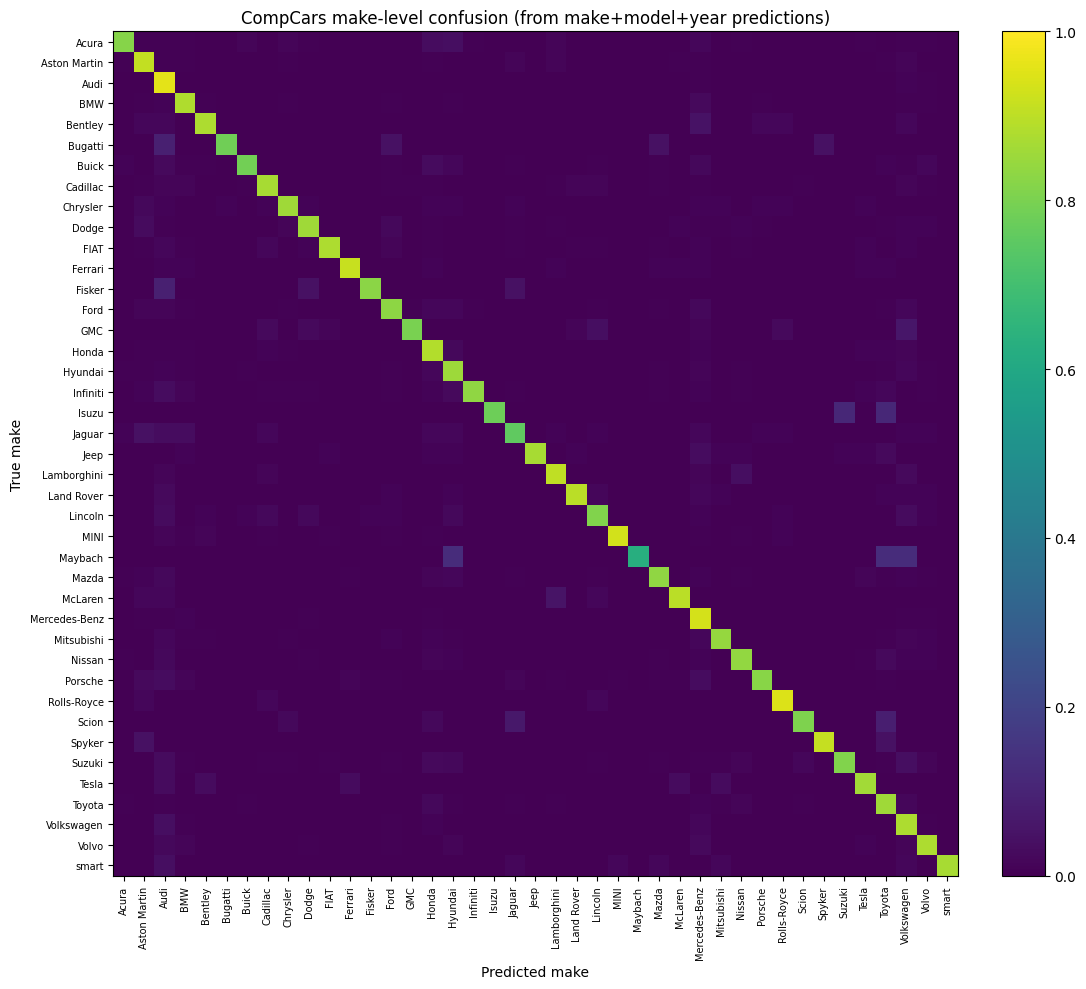

Top 15 confused make+model+year pairs (true -> predicted, count):
  Mercedes-Benz G Class AMG 2013  ->  Mercedes-Benz GL Class AMG 2013   8
  Ford New Focus hatchback 2012  ->  Ford New Focus sedan 2012   7
  Aston Martin Rapide 2013  ->  Aston Martin Rapide 2014   6
  Mazda Axela hatchback 2014  ->  Mazda Axela sedan 2014   6
  Mercedes-Benz V Class 2015  ->  Mercedes-Benz V Class 2014   6
  Toyota Sequoia 2010  ->  Toyota Sequoia 2011   6
  BMW Active Tourer 2015  ->  BMW 2 Series Active Tourer 2014   5
  McLaren 650S 2014  ->  McLaren 650S 2015   5
  Mercedes-Benz GL Class AMG 2013  ->  Mercedes-Benz G Class AMG 2013   5
  Mercedes-Benz CLS Class AMG 2015  ->  Mercedes-Benz CLS Class AMG 2014   5
  Bentley Mulsanne 2011  ->  Bentley Mulsanne 2013   4
  Chrysler 200 2015  ->  Chrysler 200 2014   4
  Audi S4 2013  ->  Audi S3 sedan 2015   4
  Mazda 8 2013  ->  Mazda 8 2011   4
  Mazda ATENZA 2013  ->  Mazda 7 Wagon 2013   4


In [15]:
makes_sorted = sorted(set(pred_df["true_make"]) | set(pred_df["pred_make"]))
mk_idx = {m_: i for i, m_ in enumerate(makes_sorted)}
yt_make = pred_df["true_make"].map(mk_idx).values
yp_make = pred_df["pred_make"].map(mk_idx).values
cm = confusion_matrix(yt_make, yp_make, labels=list(range(len(makes_sorted))))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axc = plt.subplots(figsize=(12, 10))
im = axc.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
axc.set_xticks(range(len(makes_sorted))); axc.set_yticks(range(len(makes_sorted)))
axc.set_xticklabels(makes_sorted, rotation=90, fontsize=7)
axc.set_yticklabels(makes_sorted, fontsize=7)
axc.set_xlabel("Predicted make"); axc.set_ylabel("True make")
axc.set_title("CompCars make-level confusion (from make+model+year predictions)")
fig.colorbar(im, ax=axc, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_make.png", dpi=150)
plt.show()

wrong = pred_df[~pred_df["correct_exact"]]
top_conf = (wrong.groupby(["true_class", "pred_class"]).size()
            .sort_values(ascending=False).head(15))
print("Top 15 confused make+model+year pairs (true -> predicted, count):")
for (tc, pc), c in top_conf.items():
    print(f"  {tc}  ->  {pc}   {c}")

## 12. Saved artifacts & notes

In [16]:
print("Artifacts in", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name:30s} {p.stat().st_size/1e6:7.2f} MB")

Artifacts in /kaggle/working/compcars_efficientnet_b0_mmy_fixed
  best_model.pt                    24.72 MB
  class_label_map.json              0.37 MB
  compcars_mmy_index_filtered.csv   18.69 MB
  confusion_matrix_make.png         0.14 MB
  metrics_summary.csv               0.00 MB
  metrics_summary.json              0.00 MB
  per_class_report.csv              0.09 MB
  predictions.csv                   2.24 MB
  test_split.csv                    2.80 MB
  train_config.json                 0.00 MB
  train_split.csv                  13.08 MB
  training_curves.png               0.09 MB
  training_history.json             0.00 MB
  val_split.csv                     2.80 MB



### Notes for reporting this experiment

* This is a **CompCars-only experiment**.
* The exact target is `make + model + year`, which is harder than make/model-only
  classification because it creates many more classes with fewer images per class.
* We keep `MIN_IMAGES_PER_CLASS = 15` only for this year-level experiment so every
  remaining class can appear in train, validation, and test sets.
